In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/project_NN/Segmentation.csv",
    sep=";"
)

df.head()

,video_id,repetition_number,exercise_id,person_id,first_frame,last_frame,cam17_orientation,mocap_erroneous,exercise_subtype,lights_on,extra_person_in_cam17,extra_person_in_cam18,correctness
0,PM_000,1,1,1,180,377,front,0,right arm,0,3,0,1
1,PM_000,2,1,1,378,620,front,0,right arm,0,3,0,1
2,PM_000,3,1,1,621,865,front,0,right arm,0,3,0,1
3,PM_000,4,1,1,866,1085,front,0,right arm,0,3,3,1
4,PM_000,5,1,1,1086,1265,front,0,right arm,0,3,3,1


In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/project_NN/2d_joints.zip"
extract_path = "/content/2d_joints"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

print("Done extracting")

Done extracting


In [ ]:
import os

print(os.listdir(extract_path))

['Ex1', 'Ex4', 'Ex6', 'Ex2', 'Ex3', 'Ex5']


In [ ]:
import os
import numpy as np

ex_path = "/content/2d_joints/Ex1"

files = os.listdir(ex_path)
print(files[:5])

['PM_122-c17-30fps.npy', 'PM_000-c18-30fps.npy', 'PM_000-c18-120fps.npy', 'PM_032-c18-30fps.npy', 'PM_039-c17-120fps.npy']


In [ ]:
sample_file = os.path.join(ex_path, files[0])

data = np.load(sample_file)
print(data.shape)

(3740, 26, 2)


In [ ]:
all_npy_files = []

for ex in os.listdir(base_path):
    ex_path = os.path.join(base_path, ex)

    for file in os.listdir(ex_path):
        if file.endswith(".npy"):
            all_npy_files.append(os.path.join(ex_path, file))

print(len(all_npy_files))
print(all_npy_files[:3])

260
['/content/2d_joints/Ex1/PM_122-c17-30fps.npy', '/content/2d_joints/Ex1/PM_000-c18-30fps.npy', '/content/2d_joints/Ex1/PM_000-c18-120fps.npy']


In [ ]:
X = []
y = []

for file in all_npy_files:
    data = np.load(file)

    data = data.reshape(data.shape[0], -1)  # (T, 52)

    X.append(data)

# y لسه هنربطه بـ CSV بعدين

In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/project_NN/Segmentation.csv", sep=";")

label_map = dict(zip(df["video_id"], df["correctness"]))

In [ ]:
import os

def get_video_id(path):
    filename = os.path.basename(path)
    return filename.split("-")[0]   # PM_000

In [ ]:
import numpy as np

X = []
y = []

for file in all_npy_files:
    vid = get_video_id(file)

    if vid in label_map:
        data = np.load(file)
        data = data.reshape(data.shape[0], -1)  # (T, 52)

        X.append(data)
        y.append(label_map[vid])

In [ ]:
import numpy as np
import os

test_X = []
test_y = []

for file in all_npy_files[:5]:
    vid = os.path.basename(file).split("-")[0]

    if vid in label_map:
        data = np.load(file)
        data = data.reshape(data.shape[0], -1)

        test_X.append(data)
        test_y.append(label_map[vid])

        print("File:", file)
        print("Video ID:", vid)
        print("Label:", label_map[vid])
        print("Shape:", data.shape)
        print("-" * 50)

File: /content/2d_joints/Ex1/PM_122-c17-30fps.npy
Video ID: PM_122
Label: 0
Shape: (3740, 52)
--------------------------------------------------
File: /content/2d_joints/Ex1/PM_000-c18-30fps.npy
Video ID: PM_000
Label: 1
Shape: (1304, 52)
--------------------------------------------------
File: /content/2d_joints/Ex1/PM_000-c18-120fps.npy
Video ID: PM_000
Label: 1
Shape: (5215, 52)
--------------------------------------------------
File: /content/2d_joints/Ex1/PM_032-c18-30fps.npy
Video ID: PM_032
Label: 0
Shape: (2951, 52)
--------------------------------------------------
File: /content/2d_joints/Ex1/PM_039-c17-120fps.npy
Video ID: PM_039
Label: 0
Shape: (15211, 52)
--------------------------------------------------


In [ ]:
import numpy as np

MAX_LEN = 2000

def fix_sequence_length(data, max_len=MAX_LEN):
    seq_len, features = data.shape

    # 🟢 لو أطول → Sampling (قص)
    if seq_len > max_len:
        return data[:max_len]

    # 🟢 لو أقصر → Padding
    else:
        pad_size = max_len - seq_len
        padding = np.zeros((pad_size, features))
        return np.vstack((data, padding))

In [ ]:
X = []
y = []

for file in all_npy_files:
    vid = os.path.basename(file).split("-")[0]

    if vid in label_map:
        data = np.load(file)

        # flatten joints (26,2) → 52
        data = data.reshape(data.shape[0], -1)

        # fix length
        data = fix_sequence_length(data)

        X.append(data)
        y.append(label_map[vid])

In [ ]:
X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(260, 2000, 52)
(260,)


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1])

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = {
    0: class_weights[0],
    1: class_weights[1]
}

print(class_weight_dict)

{0: np.float64(0.5416666666666666), 1: np.float64(6.5)}


# **Sliding Window**

In [ ]:
WINDOW_SIZE = 200
STRIDE = 100   # overlap

In [ ]:
def sliding_window(data, window_size=200, stride=100):
    samples = []

    for start in range(0, len(data) - window_size + 1, stride):
        end = start + window_size
        window = data[start:end]
        samples.append(window)

    return samples

In [ ]:
X = []
y = []

for file in all_npy_files:
    vid = os.path.basename(file).split("-")[0]

    if vid in label_map:
        data = np.load(file)
        data = data.reshape(data.shape[0], -1)  # (T, 52)

        windows = sliding_window(data, 200, 100)

        for w in windows:
            X.append(w)
            y.append(label_map[vid])

In [ ]:
print(np.array(X).shape)

(18256, 200, 52)


# **Bulding Model**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# *Residual Block*

In [ ]:
def residual_block(x, filters, kernel_size=3):
    shortcut = x

    x = layers.Conv1D(filters, kernel_size, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv1D(filters, kernel_size, padding="same")(x)
    x = layers.BatchNormalization()(x)

    # Skip connection
    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)

    return x

# *Build Model*

In [ ]:
input_shape = (2000, 52)

inputs = layers.Input(shape=input_shape)

x = layers.Conv1D(64, 7, padding="same")(inputs)
x = layers.BatchNormalization()(x)
x = layers.ReLU()(x)

# Residual blocks
x = residual_block(x, 64)
x = residual_block(x, 64)
x = residual_block(x, 64)

x = layers.GlobalAveragePooling1D()(x)

x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1, activation="sigmoid")(x)

model = Model(inputs, outputs)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 2000, 52)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 2000, 64)  │     23,360 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2000, 64)  │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 2000, 64)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 2000, 64)  │     12,352 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2000, 64)  │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 2000, 64)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 2000, 64)  │     12,352 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2000, 64)  │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 2000, 64)  │          0 │ batch_normalizat… │
│                     │                   │            │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 2000, 64)  │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 2000, 64)  │     12,352 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2000, 64)  │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 2000, 64)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 2000, 64)  │     12,352 │ re_lu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2000, 64)  │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 2000, 64)  │          0 │ batch_normalizat… │
│                     │                   │            │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 2000, 64)  │          0 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 2000, 64)  │     12,352 │ re_lu_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2000, 64)  │        256 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 103,489 (404.25 KB)

 Trainable params: 102,593 (400.75 KB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    np.array(X),
    np.array(y),
    test_size=0.2,
    stratify=y
)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=8,
    class_weight={
        0: 0.5417,
        1: 6.5
    }
)

Epoch 1/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 102s 55ms/step - accuracy: 0.6860 - loss: 0.5520 - val_accuracy: 0.9307 - val_loss: 0.2644
Epoch 2/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 94s 52ms/step - accuracy: 0.7259 - loss: 0.5252 - val_accuracy: 0.6032 - val_loss: 0.9717
Epoch 3/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 95s 52ms/step - accuracy: 0.7665 - loss: 0.4936 - val_accuracy: 0.9157 - val_loss: 0.2455
Epoch 4/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 95s 52ms/step - accuracy: 0.7450 - loss: 0.4756 - val_accuracy: 0.6172 - val_loss: 0.7154
Epoch 5/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 145s 54ms/step - accuracy: 0.7690 - loss: 0.4521 - val_accuracy: 0.7473 - val_loss: 0.4725
Epoch 6/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 96s 52ms/step - accuracy: 0.7864 - loss: 0.4378 - val_accuracy: 0.9255 - val_loss: 0.2525
Epoch 7/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 140s 52ms/step - accuracy: 0.7920 - loss: 0.4317 - val_accuracy: 0.8275 - val_loss: 0.3758
Epoch 8/20
1826/1826 ━━━━━━━━━━━━━━━━━━━━ 95s 52ms/step - accuracy: 0.810

In [ ]:
model.save("resnet1d_model.h5")

In [ ]:
model.save("/content/drive/MyDrive/resnet1d_model.h5")

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("/content/drive/MyDrive/resnet1d_model.h5")

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

115/115 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.8850 - loss: 0.2024
Test Accuracy: 0.8849945068359375
Test Loss: 0.20239922404289246


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# predictions
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int).flatten()

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

115/115 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step
Confusion Matrix:
 [[2997  411]
 [   9  235]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.88      0.93      3408
           1       0.36      0.96      0.53       244

    accuracy                           0.88      3652
   macro avg       0.68      0.92      0.73      3652
weighted avg       0.95      0.88      0.91      3652



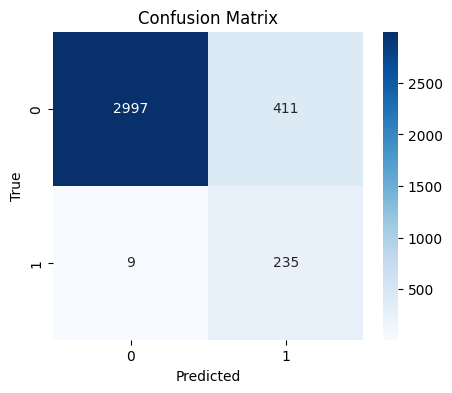

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# **Camera inference**

In [ ]:
!pip install opencv-python mediapipe --quiet

In [ ]:
import cv2

cap = cv2.VideoCapture(0)

print("فتحت الكاميرا... اضغط 'q' عشان تخرجي")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    cv2.putText(frame, "Camera Test - Press q to exit", (10, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    cv2.imshow('Camera Test', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

فتحت الكاميرا... اضغط 'q' عشان تخرجي


In [ ]:
import cv2
import numpy as np
import mediapipe as mp

# MediaPipe Setup
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
pose = mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5)

print("🎥 الكاميرا شغالة مع MediaPipe")
print("اضغط 'q' عشان تخرجي")

cap = cv2.VideoCapture(0)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    frame = cv2.flip(frame, 1)
    rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    results = pose.process(rgb)

    if results.pose_landmarks:
        # رسم الهيكل العظمي
        mp_drawing.draw_landmarks(
            frame,
            results.pose_landmarks,
            mp_pose.POSE_CONNECTIONS
        )

        cv2.putText(frame, "Skeleton Detected", (10, 50),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    cv2.imshow('Physio Camera', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

ImportError: cannot import name 'runtime_version' from 'google.protobuf' (/usr/local/lib/python3.12/dist-packages/google/protobuf/__init__.py)